In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np


import geopandas as gpd
import json

In [28]:
df = gpd.read_file('intersection_issue_sample.geojson')
df = df.to_crs(epsg=4326)

<AxesSubplot:>

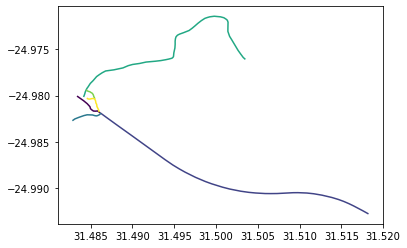

In [29]:
df.plot(cmap='viridis')

In [25]:
len(df)

4383

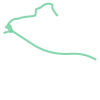

In [13]:
df.geometry.unary_union

In [27]:
#df.geometry.unary_union.wkt

In [26]:
from geojson import LineString, Feature, FeatureCollection, dump
import shapely

features = []
for geom in df.geometry.unary_union:
    g1 = shapely.wkt.loads(str(geom))
    g2 = Feature(geometry=g1, properties={})
    features.append(g2)
    #print(geom)
    
feature_collection = FeatureCollection(features)

with open('roads_all_2019_unary_union_small.geojson', 'w') as f:
    dump(feature_collection, f)

Bisher

In [5]:
df2 = df.copy()
df2 = df2.to_crs(epsg=4326)
df2.geometry = df2.geometry.buffer(0.01)

/var/folders/78/py_p37s97tl0kv_yndcm5dyw0000gn/T/ipykernel_11294/3556622941.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df2.geometry = df2.geometry.buffer(0.01)


In [6]:
un = df.geometry.unary_union
geom = [i for i in un]
id = [j for j in range(len(geom))]
unary = gpd.GeoDataFrame({"id":id,"geometry":geom})
unary = unary.set_crs(epsg=4326)
unary.head()

,id,geometry
0,0,"LINESTRING (31.48337 -24.98005, 31.48414 -24.9..."
1,1,"LINESTRING (31.48602 -24.98180, 31.48616 -24.9..."
2,2,"LINESTRING (31.48616 -24.98188, 31.48691 -24.9..."
3,3,"LINESTRING (31.48281 -24.98273, 31.48311 -24.9..."
4,4,"LINESTRING (31.50352 -24.97607, 31.50326 -24.9..."


In [7]:
len(unary)

9

In [8]:
from geopandas.tools import sjoin
result = sjoin(unary, df2, how="inner", op='intersects')
result.head()

,id,geometry,index_right,OBJECTID,ACCESS,CODE,NAME,BOUNDARY,CLASS_DEFI,SURFACE,LENGTH_KM,CLASS,Alias,Category,Type,Speed
0,0,"LINESTRING (31.48337 -24.98005, 31.48414 -24.9...",1,1521,Public,H11,Kruger Gate Road,None,Tourist Tar Road,Tar,3.554526,Tourist Tar Road,None,Transit,A1,50
1,1,"LINESTRING (31.48602 -24.98180, 31.48616 -24.9...",1,1521,Public,H11,Kruger Gate Road,None,Tourist Tar Road,Tar,3.554526,Tourist Tar Road,None,Transit,A1,50
2,2,"LINESTRING (31.48616 -24.98188, 31.48691 -24.9...",1,1521,Public,H11,Kruger Gate Road,None,Tourist Tar Road,Tar,3.554526,Tourist Tar Road,None,Transit,A1,50
3,3,"LINESTRING (31.48281 -24.98273, 31.48311 -24.9...",1,1521,Public,H11,Kruger Gate Road,None,Tourist Tar Road,Tar,3.554526,Tourist Tar Road,None,Transit,A1,50
4,4,"LINESTRING (31.50352 -24.97607, 31.50326 -24.9...",1,1521,Public,H11,Kruger Gate Road,None,Tourist Tar Road,Tar,3.554526,Tourist Tar Road,None,Transit,A1,50


In [9]:
len(result)

54

<AxesSubplot:>

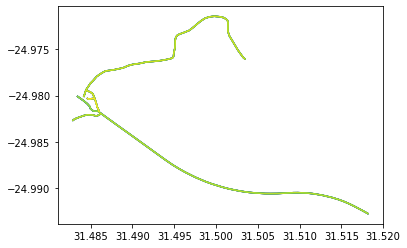

In [10]:
result.plot(cmap='viridis')

In [40]:
res = result.to_crs(epsg=4326)

In [41]:
res.to_file('intersections.geojson', driver='GeoJSON')